다음 전처리 방법에 대해 간략히 설명하고 실제 데이터에 적용

- 결측치 처리
- 이상치 처리
- 인코딩
- Scaling
- Feature Engineering(선택)

In [91]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

plt.rcParams['font.family'] = 'AppleGothic'

In [92]:


df = pd.read_csv("netflix_movies_detailed_up_to_2025.csv")

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,language,description,popularity,vote_count,vote_average,budget,revenue
0,10192,Movie,Shrek Forever After,Mike Mitchell,"Mike Myers, Eddie Murphy, Cameron Diaz, Antoni...",United States of America,2010-05-16,2010,6.380,NaN,"Comedy, Adventure, Fantasy, Animation, Family",en,A bored and domesticated Shrek pacts with deal...,203.893,7449,6.380,165000000,752600867
1,27205,Movie,Inception,Christopher Nolan,"Leonardo DiCaprio, Joseph Gordon-Levitt, Ken W...","United Kingdom, United States of America",2010-07-15,2010,8.369,NaN,"Action, Science Fiction, Adventure",en,"Cobb, a skilled thief who commits corporate es...",156.242,37119,8.369,160000000,839030630
2,12444,Movie,Harry Potter and the Deathly Hallows: Part 1,David Yates,"Daniel Radcliffe, Emma Watson, Rupert Grint, T...","United Kingdom, United States of America",2010-11-17,2010,7.744,NaN,"Adventure, Fantasy",en,"Harry, Ron and Hermione walk away from their l...",121.191,19327,7.744,250000000,954305868
3,38757,Movie,Tangled,"Byron Howard, Nathan Greno","Mandy Moore, Zachary Levi, Donna Murphy, Ron P...",United States of America,2010-11-24,2010,7.600,NaN,"Animation, Family, Adventure",en,"Feisty teenager Rapunzel, who has long and mag...",111.762,11638,7.600,260000000,592461732
4,10191,Movie,How to Train Your Dragon,"Chris Sanders, Dean DeBlois","Jay Baruchel, Gerard Butler, Craig Ferguson, A...",United States of America,2010-03-18,2010,7.800,NaN,"Fantasy, Adventure, Animation, Family",en,As the son of a Viking leader on the cusp of m...,110.044,13259,7.800,165000000,494879471


In [93]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   show_id       16000 non-null  int64  
 1   type          16000 non-null  object 
 2   title         16000 non-null  object 
 3   director      15868 non-null  object 
 4   cast          15796 non-null  object 
 5   country       15534 non-null  object 
 6   date_added    16000 non-null  object 
 7   release_year  16000 non-null  int64  
 8   rating        16000 non-null  float64
 9   duration      0 non-null      float64
 10  genres        15893 non-null  object 
 11  language      16000 non-null  object 
 12  description   15868 non-null  object 
 13  popularity    16000 non-null  float64
 14  vote_count    16000 non-null  int64  
 15  vote_average  16000 non-null  float64
 16  budget        16000 non-null  int64  
 17  revenue       16000 non-null  int64  
dtypes: float64(4), int64(5), o

| **컬럼명 (Column)** | **데이터 타입 (Dtype)** | **설명 (Description)** |
| --- | --- | --- |
| **`show_id`** | `int64` | 영화 고유 식별 번호 |
| **`type`** | `object` | 콘텐츠 유형 (모두 Movie로 구성) |
| **`title`** | `object` | 영화 제목 |
| **`director`** | `object` | 연출 감독 이름 |
| **`cast`** | `object` | 주요 출연 배우 목록 |
| **`country`** | `object` | 제작 국가 |
| **`date_added`** | `object` | 플랫폼 등록 날짜 (YYYY-MM-DD) |
| **`release_year`** | `int64` | 영화 개봉 연도 |
| **`rating`** | `float64` | 작품 평점 수치 |
| **`duration`** | `float64` | 상영 시간 (전건 결측치) |
| **`genres`** | `object` | 영화 장르 (쉼표 구분의 다중 장르) |
| **`language`** | `object` | 영화 주요 언어 코드 |
| **`description`** | `object` | 영화 줄거리 요약 |
| **`popularity`** | `float64` | TMDB 플랫폼 내 인기도 지표 |
| **`vote_count`** | `int64` | 평점 투표 참여 인원수 |
| **`vote_average`** | `float64` | 평균 사용자 평점 수치 |
| **`budget`** | `int64` | 영화 제작 예산 (USD) |
| **`revenue`** | `int64` | 박스오피스 총수익 (USD) |

In [94]:
key_numeric_cols = [
    "vote_average",
    "budget",
    "revenue",
    "popularity",
    "vote_count",
]

display(df[key_numeric_cols].describe())

,vote_average,budget,revenue,popularity,vote_count
count,16000.000000,1.600000e+04,1.600000e+04,16000.000000,16000.000000
mean,5.956368,8.766792e+06,2.446308e+07,20.384728,718.656125
std,1.754741,2.912450e+07,1.116977e+08,68.610033,2080.198316
min,0.000000,0.000000e+00,0.000000e+00,3.860000,0.000000
25%,5.600000,0.000000e+00,0.000000e+00,7.840750,53.000000
50%,6.300000,0.000000e+00,0.000000e+00,10.913500,138.000000
75%,6.923000,2.200000e+06,1.654473e+06,17.336500,422.000000
max,10.000000,4.600000e+08,2.799439e+09,3876.006000,37119.000000


In [95]:
df['genres'].describe()

count     15893
unique     2768
top       Drama
freq       1336
Name: genres, dtype: object

In [96]:
df_drop = df.copy().drop(columns=['duration', 'rating','description','type'])

In [97]:
df_drop.columns

Index(['show_id', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'genres', 'language', 'popularity', 'vote_count',
       'vote_average', 'budget', 'revenue'],
      dtype='object')

In [98]:
df_drop.head()

,show_id,title,director,cast,country,date_added,release_year,genres,language,popularity,vote_count,vote_average,budget,revenue
0,10192,Shrek Forever After,Mike Mitchell,"Mike Myers, Eddie Murphy, Cameron Diaz, Antoni...",United States of America,2010-05-16,2010,"Comedy, Adventure, Fantasy, Animation, Family",en,203.893,7449,6.380,165000000,752600867
1,27205,Inception,Christopher Nolan,"Leonardo DiCaprio, Joseph Gordon-Levitt, Ken W...","United Kingdom, United States of America",2010-07-15,2010,"Action, Science Fiction, Adventure",en,156.242,37119,8.369,160000000,839030630
2,12444,Harry Potter and the Deathly Hallows: Part 1,David Yates,"Daniel Radcliffe, Emma Watson, Rupert Grint, T...","United Kingdom, United States of America",2010-11-17,2010,"Adventure, Fantasy",en,121.191,19327,7.744,250000000,954305868
3,38757,Tangled,"Byron Howard, Nathan Greno","Mandy Moore, Zachary Levi, Donna Murphy, Ron P...",United States of America,2010-11-24,2010,"Animation, Family, Adventure",en,111.762,11638,7.600,260000000,592461732
4,10191,How to Train Your Dragon,"Chris Sanders, Dean DeBlois","Jay Baruchel, Gerard Butler, Craig Ferguson, A...",United States of America,2010-03-18,2010,"Fantasy, Adventure, Animation, Family",en,110.044,13259,7.800,165000000,494879471


In [99]:
df_valid = df_drop[df_drop["budget"] > 0].copy()
df_valid["is_profitable"] = (
    df_valid["revenue"] > df_valid["budget"]*2.0
).astype(int)

df_valid.head()

,show_id,title,director,cast,country,date_added,release_year,genres,language,popularity,vote_count,vote_average,budget,revenue,is_profitable
0,10192,Shrek Forever After,Mike Mitchell,"Mike Myers, Eddie Murphy, Cameron Diaz, Antoni...",United States of America,2010-05-16,2010,"Comedy, Adventure, Fantasy, Animation, Family",en,203.893,7449,6.380,165000000,752600867,1
1,27205,Inception,Christopher Nolan,"Leonardo DiCaprio, Joseph Gordon-Levitt, Ken W...","United Kingdom, United States of America",2010-07-15,2010,"Action, Science Fiction, Adventure",en,156.242,37119,8.369,160000000,839030630,1
2,12444,Harry Potter and the Deathly Hallows: Part 1,David Yates,"Daniel Radcliffe, Emma Watson, Rupert Grint, T...","United Kingdom, United States of America",2010-11-17,2010,"Adventure, Fantasy",en,121.191,19327,7.744,250000000,954305868,1
3,38757,Tangled,"Byron Howard, Nathan Greno","Mandy Moore, Zachary Levi, Donna Murphy, Ron P...",United States of America,2010-11-24,2010,"Animation, Family, Adventure",en,111.762,11638,7.600,260000000,592461732,1
4,10191,How to Train Your Dragon,"Chris Sanders, Dean DeBlois","Jay Baruchel, Gerard Butler, Craig Ferguson, A...",United States of America,2010-03-18,2010,"Fantasy, Adventure, Animation, Family",en,110.044,13259,7.800,165000000,494879471,1


In [100]:
df_valid.isnull().sum()

show_id           0
title             0
director          4
cast              9
country          35
date_added        0
release_year      0
genres            5
language          0
popularity        0
vote_count        0
vote_average      0
budget            0
revenue           0
is_profitable     0
dtype: int64

In [101]:
df_valid.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4847 entries, 0 to 15971
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   show_id        4847 non-null   int64  
 1   title          4847 non-null   object 
 2   director       4843 non-null   object 
 3   cast           4838 non-null   object 
 4   country        4812 non-null   object 
 5   date_added     4847 non-null   object 
 6   release_year   4847 non-null   int64  
 7   genres         4842 non-null   object 
 8   language       4847 non-null   object 
 9   popularity     4847 non-null   float64
 10  vote_count     4847 non-null   int64  
 11  vote_average   4847 non-null   float64
 12  budget         4847 non-null   int64  
 13  revenue        4847 non-null   int64  
 14  is_profitable  4847 non-null   int64  
dtypes: float64(2), int64(6), object(7)
memory usage: 605.9+ KB


In [102]:
cat_cols = ['director', 'cast', 'country', 'genres']

df_valid[cat_cols] = df_valid[cat_cols].fillna('Unknown')

df_valid.isnull().sum()

show_id          0
title            0
director         0
cast             0
country          0
date_added       0
release_year     0
genres           0
language         0
popularity       0
vote_count       0
vote_average     0
budget           0
revenue          0
is_profitable    0
dtype: int64

In [103]:
df_valid.shape

(4847, 15)

=== 수치 요약 및 왜도 ===
                      mean           50%           max   skewness
budget        2.893928e+07  1.050000e+07  4.600000e+08   3.141051
popularity    3.193484e+01  1.492200e+01  3.320616e+03  18.872295
vote_count    1.892595e+03  5.450000e+02  3.711900e+04   3.727900
vote_average  6.262280e+00  6.400000e+00  1.000000e+01  -2.487201

=== IQR 기준 이상치 개수 ===
- budget: 579개 (11.95%) | 상한선: 69,153,000.00
- popularity: 521개 (10.75%) | 상한선: 54.93
- vote_count: 536개 (11.06%) | 상한선: 4,773.50
- vote_average: 157개 (3.24%) | 상한선: 8.80


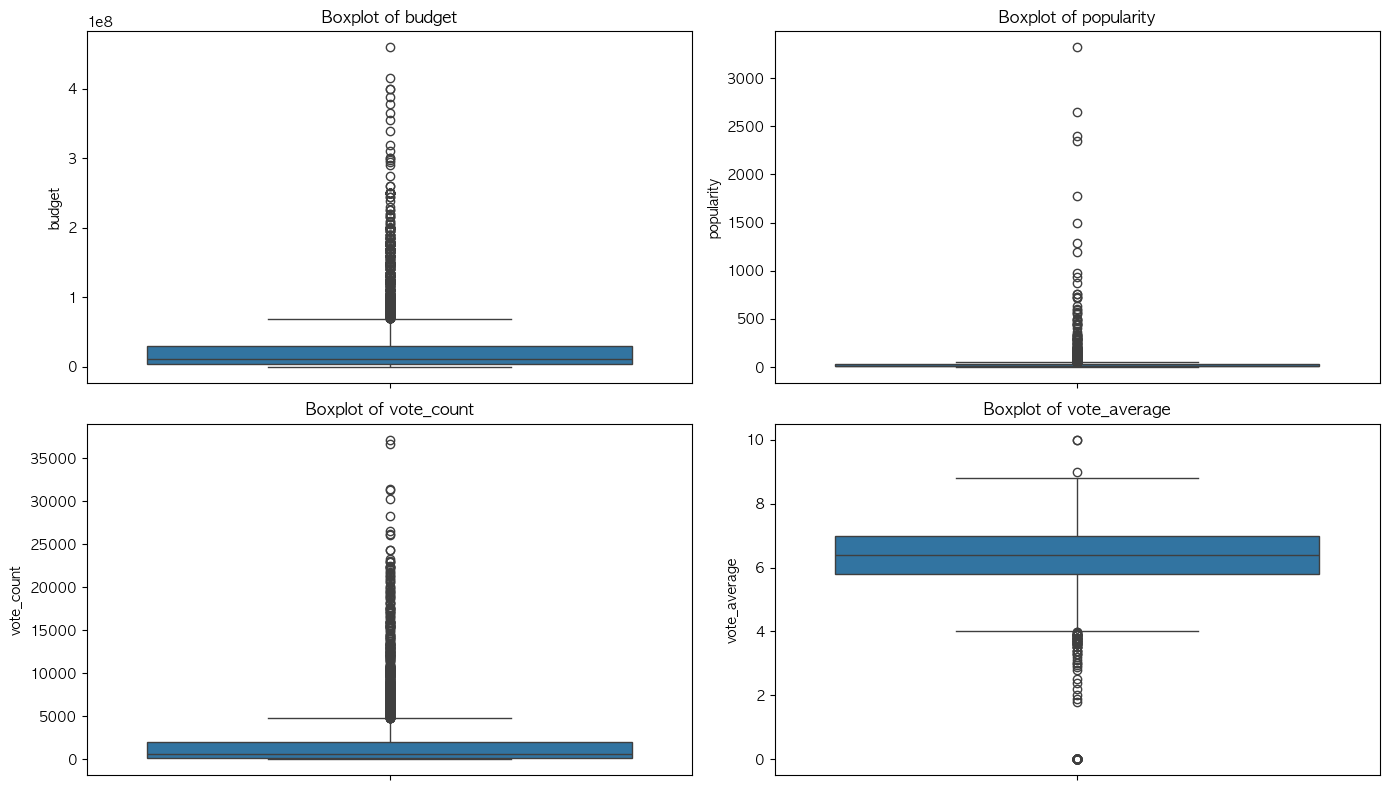

In [104]:
# 수치형 피처 지정
num_cols = ['budget', 'popularity', 'vote_count', 'vote_average']

# 1. 수치 요약 및 왜도(Skewness) 확인
stats = df_valid[num_cols].describe().T
stats['skewness'] = df_valid[num_cols].skew()
print("=== 수치 요약 및 왜도 ===")
print(stats[['mean', '50%', 'max', 'skewness']])

# 2. IQR(Interquartile Range) 기준 이상치 개수 확인
print("\n=== IQR 기준 이상치 개수 ===")
for col in num_cols:
    Q1 = df_valid[col].quantile(0.25)
    Q3 = df_valid[col].quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + 1.5 * IQR
    lower_bound = Q1 - 1.5 * IQR
    
    outliers = df_valid[(df_valid[col] < lower_bound) | (df_valid[col] > upper_bound)]
    print(f"- {col}: {len(outliers)}개 ({len(outliers)/len(df_valid)*100:.2f}%) | 상한선: {upper_bound:,.2f}")

# 3. 박스플롯(Boxplot) 시각화
plt.figure(figsize=(14, 8))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(y=df_valid[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

In [105]:

df_valid['budget_log'] = np.log1p(df_valid['budget'])
df_valid['popularity_log'] = np.log1p(df_valid['popularity'])
df_valid['vote_count_log'] = np.log1p(df_valid['vote_count'])


df_valid = df_valid.drop(columns=['budget', 'popularity', 'vote_count'])

df_valid.head()

,show_id,title,director,cast,country,date_added,release_year,genres,language,vote_average,revenue,is_profitable,budget_log,popularity_log,vote_count_log
0,10192,Shrek Forever After,Mike Mitchell,"Mike Myers, Eddie Murphy, Cameron Diaz, Antoni...",United States of America,2010-05-16,2010,"Comedy, Adventure, Fantasy, Animation, Family",en,6.380,752600867,1,18.921456,5.322488,8.915969
1,27205,Inception,Christopher Nolan,"Leonardo DiCaprio, Joseph Gordon-Levitt, Ken W...","United Kingdom, United States of America",2010-07-15,2010,"Action, Science Fiction, Adventure",en,8.369,839030630,1,18.890684,5.057786,10.521911
2,12444,Harry Potter and the Deathly Hallows: Part 1,David Yates,"Daniel Radcliffe, Emma Watson, Rupert Grint, T...","United Kingdom, United States of America",2010-11-17,2010,"Adventure, Fantasy",en,7.744,954305868,1,19.336971,4.805585,9.869310
3,38757,Tangled,"Byron Howard, Nathan Greno","Mandy Moore, Zachary Levi, Donna Murphy, Ron P...",United States of America,2010-11-24,2010,"Animation, Family, Adventure",en,7.600,592461732,1,19.376192,4.725279,9.362117
4,10191,How to Train Your Dragon,"Chris Sanders, Dean DeBlois","Jay Baruchel, Gerard Butler, Craig Ferguson, A...",United States of America,2010-03-18,2010,"Fantasy, Adventure, Animation, Family",en,7.800,494879471,1,18.921456,4.709927,9.492507


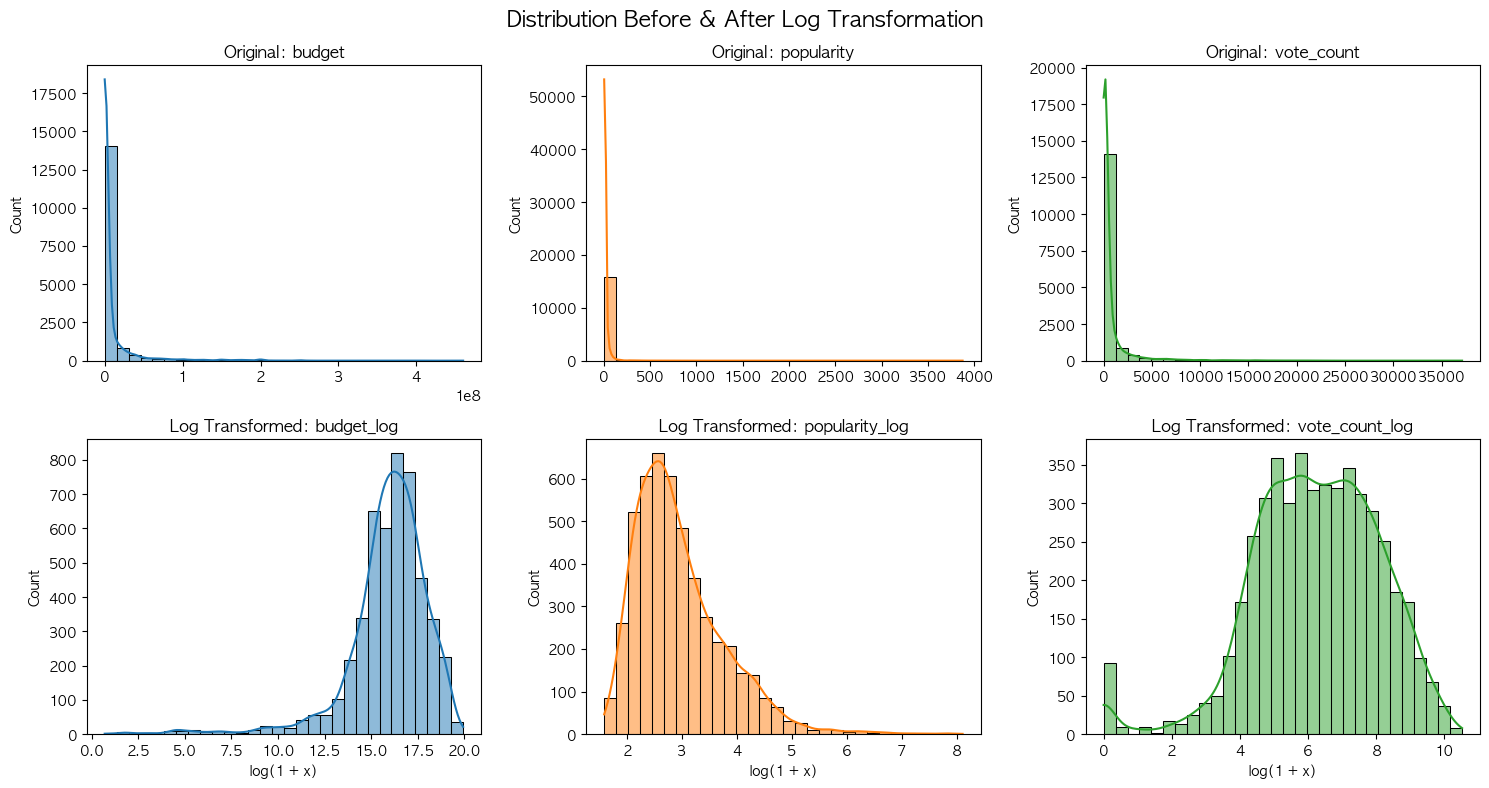

In [106]:
# 시각화할 수치 피처 목록
cols = ['budget', 'popularity', 'vote_count']

# 변환 전후 비교 그래프 생성 (2행 3열)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Distribution Before & After Log Transformation', fontsize=16, fontweight='bold')

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for i, col in enumerate(cols):
    # 1. 로그 변환 전 (원본)
    sns.histplot(df_valid[col] if col in df_valid.columns else df[col], 
                 kde=True, ax=axes[0, i], color=colors[i], bins=30)
    axes[0, i].set_title(f'Original: {col}', fontsize=12, fontweight='bold')
    axes[0, i].set_xlabel('')
    axes[0, i].set_ylabel('Count')

    # 2. 로그 변환 후
    sns.histplot(df_valid[f'{col}_log'], kde=True, ax=axes[1, i], color=colors[i], bins=30)
    axes[1, i].set_title(f'Log Transformed: {col}_log', fontsize=12, fontweight='bold')
    axes[1, i].set_xlabel('log(1 + x)')
    axes[1, i].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [107]:
df_valid['genres'].value_counts()

genres
Drama                                                          340
Comedy                                                         219
Comedy, Drama                                                  129
Drama, Romance                                                 122
Horror, Thriller                                               116
                                                              ... 
Fantasy, Action, Adventure, Horror                               1
Thriller, Drama, Adventure, Action, History                      1
Action, Adventure, Drama, Horror, Science Fiction, Thriller      1
Family, Adventure, Comedy, Music, Animation                      1
Animation, Science Fiction, Thriller, Mystery                    1
Name: count, Length: 1306, dtype: int64

In [108]:
df_encoded = df_valid.copy()


In [109]:
genres_encoded = df_encoded['genres'].str.get_dummies(sep=', ').add_prefix('genre_')
df_encoded = pd.concat([df_encoded.drop(columns=['genres']), genres_encoded], axis=1)

df_encoded.columns

Index(['show_id', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'language', 'vote_average', 'revenue', 'is_profitable',
       'budget_log', 'popularity_log', 'vote_count_log', 'genre_Action',
       'genre_Adventure', 'genre_Animation', 'genre_Comedy', 'genre_Crime',
       'genre_Documentary', 'genre_Drama', 'genre_Family', 'genre_Fantasy',
       'genre_History', 'genre_Horror', 'genre_Music', 'genre_Mystery',
       'genre_Romance', 'genre_Science Fiction', 'genre_TV Movie',
       'genre_Thriller', 'genre_Unknown', 'genre_War', 'genre_Western'],
      dtype='object')

In [110]:
df_encoded.head(2)

,show_id,title,director,cast,country,date_added,release_year,language,vote_average,revenue,...,genre_Horror,genre_Music,genre_Mystery,genre_Romance,genre_Science Fiction,genre_TV Movie,genre_Thriller,genre_Unknown,genre_War,genre_Western
0,10192,Shrek Forever After,Mike Mitchell,"Mike Myers, Eddie Murphy, Cameron Diaz, Antoni...",United States of America,2010-05-16,2010,en,6.380,752600867,...,0,0,0,0,0,0,0,0,0,0
1,27205,Inception,Christopher Nolan,"Leonardo DiCaprio, Joseph Gordon-Levitt, Ken W...","United Kingdom, United States of America",2010-07-15,2010,en,8.369,839030630,...,0,0,0,0,1,0,0,0,0,0


In [111]:
df_encoded['language'].value_counts()

language
en    3517
fr     303
es     153
hi     145
zh      94
ko      78
ru      77
it      71
ja      47
de      33
pt      31
no      30
ta      28
cn      27
da      27
te      21
fi      20
sv      16
pl      15
ml      11
tr      11
nl      10
id       8
th       7
hu       6
et       5
ar       5
tl       4
uk       4
ro       4
ca       4
is       3
fa       3
cs       3
he       3
sr       3
bn       2
kn       2
gl       2
ms       2
lv       2
la       1
ga       1
vi       1
kk       1
ku       1
mr       1
xx       1
hr       1
el       1
af       1
Name: count, dtype: int64

In [112]:
top5_langs = df_encoded['language'].value_counts().head(5).index.tolist()
df_encoded['lang_clean'] = df_encoded['language'].apply(lambda x: x if x in top5_langs else 'Other')

lang_encoded = pd.get_dummies(df_encoded['lang_clean'], prefix='lang', dtype=int)
df_encoded = pd.concat([df_encoded.drop(columns=['language', 'lang_clean']), lang_encoded], axis=1)

df_encoded.shape

(4847, 39)

In [114]:
df_encoded.head(2)

,show_id,title,director,cast,country,date_added,release_year,vote_average,revenue,is_profitable,...,genre_Thriller,genre_Unknown,genre_War,genre_Western,lang_Other,lang_en,lang_es,lang_fr,lang_hi,lang_zh
0,10192,Shrek Forever After,Mike Mitchell,"Mike Myers, Eddie Murphy, Cameron Diaz, Antoni...",United States of America,2010-05-16,2010,6.380,752600867,1,...,0,0,0,0,0,1,0,0,0,0
1,27205,Inception,Christopher Nolan,"Leonardo DiCaprio, Joseph Gordon-Levitt, Ken W...","United Kingdom, United States of America",2010-07-15,2010,8.369,839030630,1,...,0,0,0,0,0,1,0,0,0,0


In [115]:
df_encoded['country'].value_counts()

country
United States of America                                2032
United Kingdom, United States of America                 204
India                                                    192
France                                                   149
United Kingdom                                           109
                                                        ... 
France, Greece, Ireland, Netherlands, United Kingdom       1
France, Hungary, Spain, United States of America           1
United Kingdom, Germany, United States of America          1
Chile, Germany, United States of America                   1
Austria, Belgium, France, Georgia                          1
Name: count, Length: 740, dtype: int64

In [117]:
top10_countries = ['United States of America', 'United Kingdom', 'France', 
                   'Canada', 'India', 'Germany', 'China', 'Belgium', 'Spain', 'Italy']

for country in top10_countries:
    col_name = 'country_' + country.replace(' ', '_')
    df_encoded[col_name] = df_encoded['country'].apply(
        lambda x: 1 if country in [c.strip() for c in str(x).split(',')] else 0
    )

top10_cols = ['country_' + c.replace(' ', '_') for c in top10_countries]
df_encoded['country_Other'] = (df_encoded[top10_cols].sum(axis=1) == 0).astype(int)

df_encoded = df_encoded.drop(columns=['country'])

df_encoded.shape[1]

49

In [118]:
from sklearn.model_selection import train_test_split

# 1. 모델 학습에서 제외할 컬럼 정의 (Data Leakage 및 미인코딩 문자열 컬럼)
drop_cols = ['revenue', 'is_profitable', 'id', 'title', 'release_date', 'director', 'cast']

# 실제 데이터프레임에 존재하는 컬럼만 필터링 (KeyError 방지)
existing_drop_cols = [col for col in drop_cols if col in df_encoded.columns]

# 2. 독립변수(X)와 종속변수/타겟(y) 분리
X = df_encoded.drop(columns=existing_drop_cols)
y = df_encoded['is_profitable']

# 3. Train / Test 분할 (8:2 비율, 클래스 불균형 방지를 위한 stratify 적용)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

# 4. 독립변수(X)와 종속변수(y)를 하나로 합쳐 파일로 저장
train_df = pd.concat([X_train, y_train], axis=1)
test_df = pd.concat([X_test, y_test], axis=1)

train_df.to_csv('train.csv', index=False)
test_df.to_csv('test.csv', index=False)

print(f"train.csv 생성 완료: {train_df.shape} (타겟 비율: {y_train.mean():.2%})")
print(f"test.csv 생성 완료: {test_df.shape} (타겟 비율: {y_test.mean():.2%})")

train.csv 생성 완료: (3877, 45) (타겟 비율: 32.99%)
test.csv 생성 완료: (970, 45) (타겟 비율: 32.99%)
